                            Assignment 2
1.Install & Import Required Libraries;
    -pandas: to read the the data from csv gile and convert it into dataframe
    -numpy: Numerical computing (arrays, mathematical operations)
    -sklearn.model_selection:
         .train_test_split: Splits data into training and test sets
         .cross_val_score: Performs cross-validation
         .GridSearchCV: Hyperparameter tuning
    -sklearn.preprocessing:
         .LabelEncoder: Converts categorical labels to numerical values
    -sklearn.metrics: Evaluation metrics for classification:
          accuracy_score, precision_score, recall_score, f1_score
          confusion_matrix, classification_report
    -sklearn classifiers:
         .DecisionTreeClassifier: Single decision tree
         .RandomForestClassifier: Ensemble of decision trees
         .AdaBoostClassifier: Adaptive boosting ensemble
         .GaussianNB: Naive Bayes classifier with Gaussian distribution
    -matplotlib.pyplot (plt): Basic plotting
    -seaborn (sns): Advanced statistical visualizations

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import seaborn as sns


2.load and process the dataset;
      -fist, this code defines the colum names as they are not defined in the dataser
      -then,Reads the dataset from the file magic041.data,Uses the column_names list to name the columns amdLoads the data             into a pandas DataFrame called df.
      -The 'class' column originally contains string labels: 'g' (gamma) and 'h' (hadron), so we convert thm into binary               numeric values  g willl be 1 and h will be 0
      -balance the dataset:separate gamma and hadron samples,Randomly selects a subset of gamma rows equal to the number of            hadron rows, to avoid class imbalance.Concatenates the sampled gamma rows and all hadron rows vertically.
        This results in a balanced dataset where both classes have the same number of samples.Shuffles all rows of the                 balanced dataset and Resets the row indices after shuffling.

In [2]:

column_names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym',
    'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class'
]
df = pd.read_csv('magic041.data', names=column_names)


df['class'] = df['class'].map({'g': 1, 'h': 0})


gamma = df[df['class'] == 1]
hadron = df[df['class'] == 0]

balanced_df = pd.concat([gamma.sample(len(hadron), random_state=42), hadron], axis=0)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle


3.split the dataset;
     -separate the features and the target as you put all the colums except the class column to variable x and put the class          column to valiable y
     -split the data to be 70% for traing and the rest 30% for testing

In [3]:
X = balanced_df.drop('class', axis=1)
y = balanced_df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


4.function helping in evaluation;
        -Predicts test results using your model.
        -Calculates accuracy, precision, recall, and F1-score.(compareson between y test and y predict)
        -Displays those metrics and a confusion matrix.
        -Returns the metrics for further analysis.

In [4]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-Score:", f1)
    print("Confusion Matrix:\n", cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return acc, prec, rec, f1


4.train the model;

 Decision tree model:
     -intialize the decision tree calssifier
     -train the decision tree model on the training data
     -call the evaluate model function to:
          .Predict the labels for the test data using tree classifier
          .Compute and print accuracy, precision, recall, F1-score.
          .Plot the confusion matrix.
          .The returned metrics are stored in dt_results as a tuple:
              (accuracy, precision, recall, f1_score)

Decision Tree Results:
Accuracy: 0.785447296287067
Precision: 0.7764005949429846
Recall: 0.7925101214574899
F1-Score: 0.7843726521412472
Confusion Matrix:
 [[1586  451]
 [ 410 1566]]


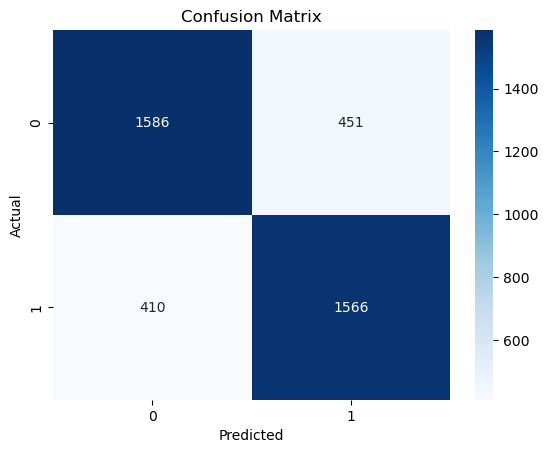

In [5]:
print("Decision Tree Results:")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_results = evaluate_model(dt, X_test, y_test)


Naive bayes model:
     -intialize the naive bayes model
     -train the naive bayes model on the traing data
     -call the evaluate model function to:
          .Predict the labels for the test data using naive classifier
          .Compute and print accuracy, precision, recall, F1-score.
          .Plot the confusion matrix.
          .The returned metrics are stored in nb_results as a tuple:
              (accuracy, precision, recall, f1_score)

Naïve Bayes Results:
Accuracy: 0.6421629703463743
Precision: 0.5904219691895513
Recall: 0.8922064777327935
F1-Score: 0.7106005642885933
Confusion Matrix:
 [[ 814 1223]
 [ 213 1763]]


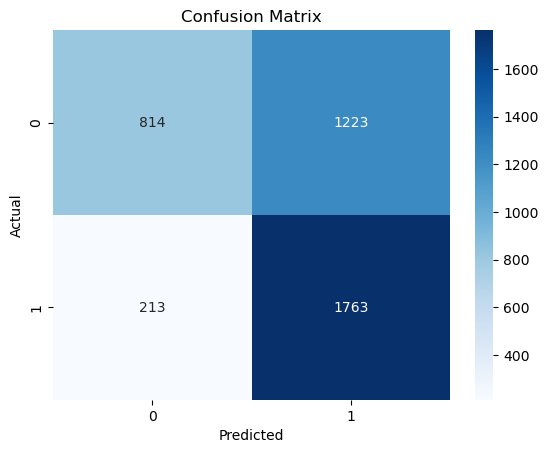

In [6]:
print("Naïve Bayes Results:")
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_results = evaluate_model(nb, X_test, y_test)


random forest model:
     -intialize the random forest model
     -define a grid of values for the n_estimators parameter.
     -Wraps the base model rf with GridSearchCV which automatically selects the best n_estimators based on model performance.
     -train the naive bayes model on the traing data
     -Extracts the best version of the trained Random Forest model based on cross-validation performance.
     -call the evaluate model function to:
          .Predict the labels for the test data random forest
          .Compute and print accuracy, precision, recall, F1-score.
          .Plot the confusion matrix.
          .The returned metrics are stored in nb_results as a tuple:
              (accuracy, precision, recall, f1_score)

Random Forest Results:
Best n_estimators: {'n_estimators': 150}
Accuracy: 0.8507351108896087
Precision: 0.8264580369843528
Recall: 0.882085020242915
F1-Score: 0.8533659730722154
Confusion Matrix:
 [[1671  366]
 [ 233 1743]]


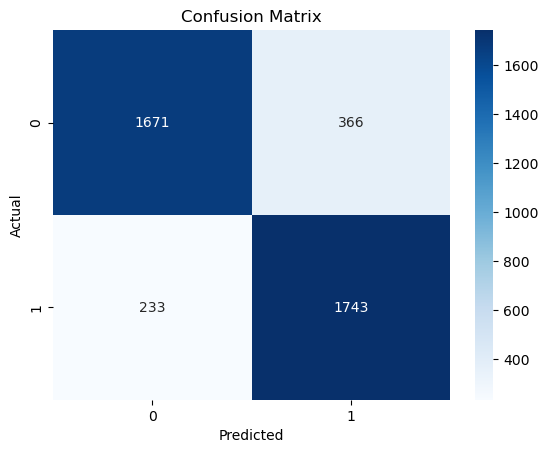

In [7]:
print("Random Forest Results:")
rf = RandomForestClassifier(random_state=42)
param_grid = {'n_estimators': [50, 100, 150]}
grid_rf = GridSearchCV(rf, param_grid, cv=5)
grid_rf.fit(X_train, y_train)
print("Best n_estimators:", grid_rf.best_params_)
rf_best = grid_rf.best_estimator_
rf_results = evaluate_model(rf_best, X_test, y_test)


Adaboost  model:
     -intialize the adaboost model
     -define a grid of values for the n_estimators parameter.
     -Wraps the base model rf with GridSearchCV which automatically selects the best n_estimators based on model performance.
     -train the adaboost on the traing data
     -Extracts the best version of the trained adaboost model based on cross-validation performance.
     -call the evaluate model function to:
          .Predict the labels for the test data using adaboost
          .Compute and print accuracy, precision, recall, F1-score.
          .Plot the confusion matrix.
          .The returned metrics are stored in nb_results as a tuple:
              (accuracy, precision, recall, f1_score)

In [ ]:
print("AdaBoost Results:")
ab = AdaBoostClassifier(random_state=42, algorithm='SAMME')
param_grid = {'n_estimators': [50, 100, 150]}
grid_ab = GridSearchCV(ab, param_grid, cv=5)
grid_ab.fit(X_train, y_train)
print("Best n_estimators:", grid_ab.best_params_)
ab_best = grid_ab.best_estimator_
ab_results = evaluate_model(ab_best, X_test, y_test)


AdaBoost Results:


6.Final comparision;
      compare between the models in a dataframe regarding the accuracy,precision,recall and the score

In [ ]:
results_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes', 'Random Forest', 'AdaBoost'],
    'Accuracy': [dt_results[0], nb_results[0], rf_results[0], ab_results[0]],
    'Precision': [dt_results[1], nb_results[1], rf_results[1], ab_results[1]],
    'Recall': [dt_results[2], nb_results[2], rf_results[2], ab_results[2]],
    'F1-Score': [dt_results[3], nb_results[3], rf_results[3], ab_results[3]]
})
print(results_df)


7.conclusion;
Decision Tree Classifier:
    -The Decision Tree model showed solid performance with 78.5% accuracy and balanced precision/recall.
    -Its simple structure allows easy interpretation, but its performance was noticeably behind ensemble methods.
    -Conclusion: A good baseline model but not the most effective for this dataset.

Naïve Bayes Classifier:
    -Naïve Bayes achieved the highest recall (89.2%) but at the cost of low precision (59.0%) and lowest overall accuracy           (64.2%).
    -This means it correctly identified most of the true positive cases but made many false positive errors.
    -Conclusion: Suitable when false negatives are more critical (e.g., catching all possible signal events), but not ideal if       precision matters.

Random Forest Classifier:
     -Top performer overall with 85.1% accuracy and the highest F1-Score (85.3%).
     -Balanced across all metrics — strong precision (82.6%) and recall (88.2%).
     -Conclusion: Best model for general-purpose use, especially when both precision and recall are important.

AdaBoost Classifier:
    -AdaBoost achieved 80.1% accuracy, very close to Decision Tree but with better overall balance in precision (80.0%) and           recall (79.4%).
    -Not as strong as Random Forest but still a reliable ensemble method.
    -Conclusion: Strong second choice, especially when slightly faster models are preferred.